Step 1: Downloading data...
Dataset URL: https://www.kaggle.com/datasets/kaggler10240/msr-data
License(s): unknown


100%|██████████| 1.47G/1.47G [00:07<00:00, 224MB/s]


/tmp/ipykernel_57/4038294387.py:17: DtypeWarning: Columns (1,20,22,23,27,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("MSR_data_cleaned.csv")


Total samples: 188636

Step 2: Balancing data...
Total balanced samples: 4000

Step 3: Cleaning code...
Cleaning done!

Step 4: Getting CodeBERT embeddings (10-15 mins)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  Processed 320/4000
  Processed 640/4000
  Processed 960/4000
  Processed 1280/4000
  Processed 1600/4000
  Processed 1920/4000
  Processed 2240/4000
  Processed 2560/4000
  Processed 2880/4000
  Processed 3200/4000
  Processed 3520/4000
  Processed 3840/4000
Embeddings shape: torch.Size([4000, 768])

Step 5: Splitting data...
Train: 2800 | Val: 600 | Test: 600

Step 6: Building Baseline MLP...
MLP Parameters: 559,746

Step 7: Training Baseline MLP...
  Epoch 5/20 — Train F1: 0.7610 | Val F1: 0.7263
  Epoch 10/20 — Train F1: 0.7959 | Val F1: 0.6282
  Epoch 15/20 — Train F1: 0.8210 | Val F1: 0.6669
  Epoch 20/20 — Train F1: 0.8418 | Val F1: 0.7256

Best Val F1: 0.7796

Step 8: Final evaluation on test set...

Baseline MLP Results:
              precision    recall  f1-score   support

        Safe       0.73      0.76      0.74       305
  Vulnerable       0.74      0.71      0.72       295

    accuracy                           0.73       600
   macro avg       0.74      0.73      0.

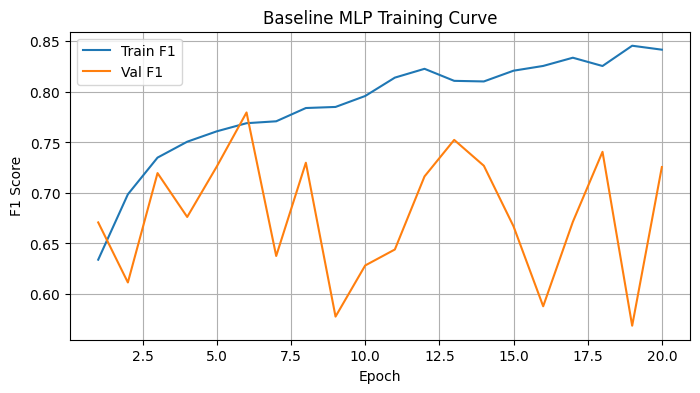

Plot saved!

Baseline MLP saved to baseline_mlp.pt
Done!


In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import f1_score, classification_report
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import subprocess

# ── Step 1: Download and load data ───────────────────────────
print("Step 1: Downloading data...")
subprocess.run(["kaggle", "datasets", "download",
                "-d", "kaggler10240/msr-data", "--unzip"], check=True)

df = pd.read_csv("MSR_data_cleaned.csv")
df = df[['func_before', 'vul']].dropna()
print(f"Total samples: {len(df)}")

# ── Step 2: Balance and sample ────────────────────────────────
print("\nStep 2: Balancing data...")
vuln = df[df['vul'] == 1].sample(n=2000, random_state=42)
safe = df[df['vul'] == 0].sample(n=2000, random_state=42)
df_balanced = pd.concat([vuln, safe]).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Total balanced samples: {len(df_balanced)}")

# ── Step 3: Clean code ────────────────────────────────────────
print("\nStep 3: Cleaning code...")
def clean_code(code):
    code = re.sub(r'//.*', '', code)
    code = re.sub(r'/\*.*?\*/', '', code, flags=re.DOTALL)
    code = re.sub(r'\n\s*\n', '\n', code)
    return code.strip()

df_balanced['clean_code'] = df_balanced['func_before'].apply(clean_code)
print("Cleaning done!")

# ── Step 4: Get CodeBERT embeddings ──────────────────────────
print("\nStep 4: Getting CodeBERT embeddings (10-15 mins)...")
tokenizer = AutoTokenizer.from_pretrained("microsoft/codebert-base")
codebert  = AutoModel.from_pretrained("microsoft/codebert-base")
codebert.eval()

def get_embeddings(texts, batch_size=32):
    all_embeddings = []
    texts = list(texts)
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        encoded = tokenizer(
            batch,
            max_length=512,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        with torch.no_grad():
            output = codebert(**encoded)
        cls_emb = output.last_hidden_state[:, 0, :]
        all_embeddings.append(cls_emb)
        if (i // batch_size + 1) % 10 == 0:
            print(f"  Processed {min(i+batch_size, len(texts))}/{len(texts)}")
    return torch.cat(all_embeddings, dim=0)

embeddings = get_embeddings(df_balanced['clean_code'])
labels     = torch.tensor(df_balanced['vul'].values, dtype=torch.long)
print(f"Embeddings shape: {embeddings.shape}")

# ── Step 5: Train/val/test split ──────────────────────────────
print("\nStep 5: Splitting data...")
n = len(embeddings)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_X, train_y = embeddings[:train_end], labels[:train_end]
val_X,   val_y   = embeddings[train_end:val_end], labels[train_end:val_end]
test_X,  test_y  = embeddings[val_end:], labels[val_end:]

print(f"Train: {len(train_X)} | Val: {len(val_X)} | Test: {len(test_X)}")

train_loader = DataLoader(TensorDataset(train_X, train_y), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(val_X,   val_y),   batch_size=64, shuffle=False)
test_loader  = DataLoader(TensorDataset(test_X,  test_y),  batch_size=64, shuffle=False)

# ── Step 6: Build Baseline MLP ───────────────────────────────
print("\nStep 6: Building Baseline MLP...")

class BaselineMLP(nn.Module):
    def __init__(self):
        super(BaselineMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(768, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )
    
    def forward(self, x):
        return self.network(x)

model_mlp = BaselineMLP()
print(f"MLP Parameters: {sum(p.numel() for p in model_mlp.parameters()):,}")

# ── Step 7: Train MLP ─────────────────────────────────────────
print("\nStep 7: Training Baseline MLP...")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_mlp.parameters(), lr=1e-3)

best_val_f1 = 0
history     = []

for epoch in range(20):
    # Training
    model_mlp.train()
    train_preds, train_labels_list = [], []
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        logits = model_mlp(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        preds = torch.argmax(logits, dim=1).numpy()
        train_preds.extend(preds)
        train_labels_list.extend(y_batch.numpy())

    # Validation
    model_mlp.eval()
    val_preds, val_labels_list = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            logits = model_mlp(X_batch)
            preds  = torch.argmax(logits, dim=1).numpy()
            val_preds.extend(preds)
            val_labels_list.extend(y_batch.numpy())

    train_f1 = f1_score(train_labels_list, train_preds,   average='macro')
    val_f1   = f1_score(val_labels_list,   val_preds, average='macro')
    history.append({'epoch': epoch+1, 'train_f1': train_f1, 'val_f1': val_f1})

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model_mlp.state_dict(), 'baseline_mlp.pt')

    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1}/20 — Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f}")

print(f"\nBest Val F1: {best_val_f1:.4f}")

# ── Step 8: Test evaluation ───────────────────────────────────
print("\nStep 8: Final evaluation on test set...")
model_mlp.load_state_dict(torch.load('baseline_mlp.pt'))
model_mlp.eval()

test_preds, test_labels_list = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        logits = model_mlp(X_batch)
        preds  = torch.argmax(logits, dim=1).numpy()
        test_preds.extend(preds)
        test_labels_list.extend(y_batch.numpy())

print("\nBaseline MLP Results:")
print(classification_report(test_labels_list, test_preds,
                             target_names=['Safe', 'Vulnerable']))
test_f1 = f1_score(test_labels_list, test_preds, average='macro')
print(f"Test F1 (macro): {test_f1:.4f}")

# ── Step 9: Plot training curve ───────────────────────────────
history_df = pd.DataFrame(history)
plt.figure(figsize=(8, 4))
plt.plot(history_df['epoch'], history_df['train_f1'], label='Train F1')
plt.plot(history_df['epoch'], history_df['val_f1'],   label='Val F1')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.title('Baseline MLP Training Curve')
plt.legend()
plt.grid(True)
plt.savefig('mlp_training_curve.png', dpi=150)
plt.show()
print("Plot saved!")

torch.save(model_mlp.state_dict(), 'baseline_mlp.pt')
print("\nBaseline MLP saved to baseline_mlp.pt")
print("Done!")